# 06 · La Torre en vivo: la campaña, semana a semana
**Torre del Caribe** · Fase 7 (A5) · Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| | |
|---|---|
| **Qué hace** | Reproduce 239 semanas reales (ene-2022 → jul-2026) y decide, cada semana, qué anuncio del sur se enciende o se pausa y cuándo ofrecer el sur a quien iba al norte. |
| **Decisiones de Brandon** | Cuatro señales (norte, tormentas, clima raro, llegadas) · pausar y guardar el dinero · "¿Ibas al norte?" cuando el norte se satura · reproducción grabada · clima raro = más raro que el 95 % (`docs/decisiones/20-torre-en-vivo.md`). |
| **Código** | `backend/torre/envivo/`: `senales.py`, `motor.py`, `torre.py`. |
| **Ecuaciones** | `docs/metodologia/ECUACIONES.md` §5. |
| **Alimenta a** | La etapa 2 del modelo de la Fase 6 (pausar y reasignar) y la campaña (Fase 8). |

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "backend"))
import pandas as pd
import matplotlib.pyplot as plt
from torre.envivo import senales as sn, motor as mt
from torre.documento.figuras import estilo_unrc, GUINDA, DORADO, GRIS_TEXTO
GOLD = RAIZ / "datos" / "gold"
estilo_unrc()
s = pd.read_parquet(GOLD / "envivo_senales.parquet")
d = pd.read_parquet(GOLD / "envivo_decisiones.parquet")
nt = pd.read_parquet(GOLD / "envivo_norte.parquet")
print(f"{len(s)} semanas: {s.semana.min():%d-%m-%Y} → {s.semana.max():%d-%m-%Y}")

239 semanas: 03-01-2022 → 27-07-2026


## 1. Señal del norte: ocupación semanal y sus cortes
Los cortes son los del Radar (Fase 4): percentiles 50 y 90 de la ocupación semanal de los 7 centros de Quintana Roo.
"Saturado" = ≥ p90. El promedio de 4 semanas sale de una ventana deslizante de Spark.

p50 = 71.16 %, p90 = 85.92 %


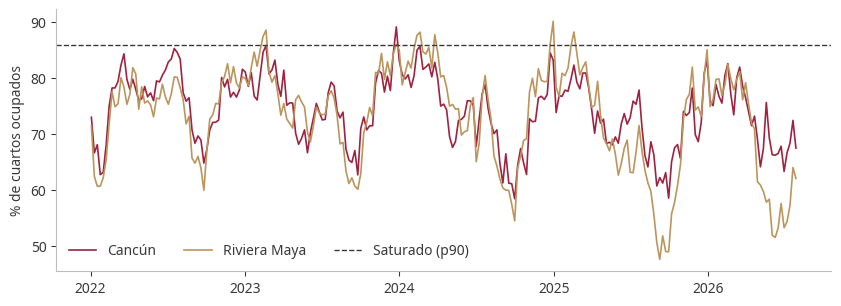

,cancun_estado,riviera_estado
concurrido,164,149
tranquilo,74,81
saturado,1,9


In [2]:
print(f"p50 = {s.corte_p50.iloc[0]:.2f} %, p90 = {s.corte_p90.iloc[0]:.2f} %")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(s.semana, s.cancun_ocupacion_pct, color=GUINDA, lw=1.2, label="Cancún")
ax.plot(s.semana, s.riviera_ocupacion_pct, color=DORADO, lw=1.2, label="Riviera Maya")
ax.axhline(s.corte_p90.iloc[0], color=GRIS_TEXTO, ls="--", lw=1, label="Saturado (p90)")
ax.set_ylabel("% de cuartos ocupados"); ax.legend(frameon=False, ncol=3); plt.show()
s[["cancun_estado", "riviera_estado"]].apply(pd.Series.value_counts).fillna(0).astype(int)

## 2. Tormentas cerca
Regla de la Fase 5: un punto de HURDAT2 a ≤ 200 km de Chetumal con viento ≥ 34 nudos. **2026 aún no se publica**: esas
semanas quedan como *sin dato*, que no es lo mismo que "sin tormenta".

In [3]:
s.groupby(s.tormenta.map({True: "tormenta", False: "sin tormenta", None: "sin dato (2026)"}).fillna("sin dato (2026)")).size(), \
    s[s.tormenta == True][["semana", "tormenta_nombre"]]

(tormenta
 sin dato (2026)     30
 sin tormenta       206
 tormenta             3
 dtype: int64,
         semana tormenta_nombre
 43  2022-10-31            Lisa
 145 2024-10-14          Nadine
 149 2024-11-11            Sara)

## 3. Clima raro con Isolation Forest
$s(x)=2^{-E[h(x)]/c(n)}$, con $c(n)=2H(n-1)-2(n-1)/n$. Un bosque por punto y por año, entrenado con todas las semanas
anteriores (ventana creciente). Una semana es rara si su $s(x)$ pasa el percentil 95 de las semanas de entrenamiento.
El corte automático (`contamination="auto"`) se descartó porque marcaba 47 % de las semanas de Chetumal.

          sum  count      mean
punto                         
chetumal   21    247   0.08502
kohunlich  17    247  0.068826


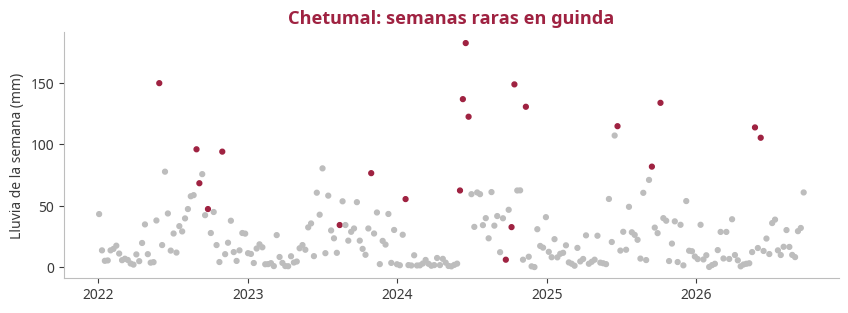

In [4]:
c = sn.anomalias_clima(sn.clima_semanal())
c = c[c.n_entrena > 0]
print(c.groupby("punto").clima_raro.agg(["sum", "count", "mean"]).round(3))
fig, ax = plt.subplots(figsize=(10, 3.2))
x = c[c.punto == "chetumal"]
ax.scatter(x.semana, x.lluvia_mm, c=x.clima_raro.map({True: GUINDA, False: "#BDBDBD"}), s=12)
ax.set_ylabel("Lluvia de la semana (mm)"); ax.set_title("Chetumal: semanas raras en guinda"); plt.show()

## 4. El motor de reglas, con un ejemplo
Sur: tormenta, clima raro en su punto o llegadas del mes anterior **por arriba** del rango del 90 % → pausa, y el dinero
pasa a la siguiente semana permitida. Norte: si Cancún o Riviera Maya están saturados → "¿Ibas al norte?" hacia el lugar
del sur encendido con más espacio libre.

In [5]:
ej = s[s.tormenta == True].iloc[0].to_dict()
plan = mt.plan_desde_gold(pd.read_parquet(GOLD / "presupuesto_plan.parquet"),
                          __import__("torre.campana.presupuesto", fromlist=["x"]).tabla_meses())
dec, nor = mt.decidir(ej, plan, mt.Memoria())
pd.DataFrame(dec)[["semana", "lugar", "accion", "motivo", "pesos_plan", "arrastre"]]

,semana,lugar,accion,motivo,pesos_plan,arrastre
0,2022-10-31,Chetumal,pausado,tormenta cerca (Lisa); clima raro (94 mm de ll...,826.59812,826.59812
1,2022-10-31,Bahía Calderitas–Oxtankah,pausado,tormenta cerca (Lisa); clima raro (94 mm de ll...,2655.25356,2655.25356
2,2022-10-31,Ruta arqueológica del sur,pausado,tormenta cerca (Lisa); clima raro (90 mm de ll...,3035.37524,3035.37524


## 5. La reproducción con Spark Structured Streaming
`python -m torre.envivo.torre` escribe una semana por archivo y Spark las lee con `maxFilesPerTrigger = 1`: cada lote es
una semana. Se comprueba que llegaron todas y en orden.

In [6]:
print(f"Lotes: {d.lote.nunique()} · semanas: {d.semana.nunique()} · en orden: {d.groupby('lote').semana.first().is_monotonic_increasing}")
print(f"Pesos gastados ${d.pesos_gastados.sum():,.0f} = planeados ${d.pesos_plan.sum():,.0f}")
display(d.pivot_table(index="lugar", columns="accion", values="semana", aggfunc="count", fill_value=0))
print(f"¿Ibas al norte?: {nt.ibas_al_norte.sum()} semanas →", nt[nt.ibas_al_norte].destino.value_counts().to_dict())

Lotes: 239 · semanas: 239 · en orden: True
Pesos gastados $876,901 = planeados $876,901


accion,encendido,fuera del plan,pausado,temporada alta
lugar,,,,
Bahía Calderitas–Oxtankah,106,57,14,62
Chetumal,145,57,19,18
Ruta arqueológica del sur,104,57,15,63


¿Ibas al norte?: 6 semanas → {'Bahía Calderitas–Oxtankah': 6}


## 6. Qué se concluye
1. **La Torre pausa poco y por razones claras:** 48 pausas de lugar-semana en 239 semanas, casi todas por clima raro. Las
   tres tormentas (Lisa 2022, Nadine y Sara 2024) pausaron los tres lugares.
2. **No se pierde dinero:** lo pausado se gasta en la siguiente semana permitida.
3. **El norte casi nunca se satura en lo semanal** (Cancún 1 semana, Riviera Maya 9): "¿Ibas al norte?" se encendió 6
   semanas. La señal útil del norte es la temporada (Fase 5), no la semana.
4. **Limitaciones:** el sur no tiene ningún dato semanal oficial; las tormentas de 2026 no se conocen; se supone que el
   dato mensual se conoce al empezar el mes siguiente; el plan de dinero es el de la Fase 6 aplicado a años pasados.